# VisDrone Label Validation and Visualization

This notebook checks if the VisDrone labels are correct in both raw and YOLO formats, and visualizes images with bounding boxes.

In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from PIL import Image
import pandas as pd
from collections import defaultdict

# Define paths
VISDRONE_ROOT = Path('/home/khanh/Projects/DifficultyAgri/datasets/VisDrone')
RAW_DIR = VISDRONE_ROOT / 'raw'
YOLO_DIR = VISDRONE_ROOT / 'yolo_format' / 'visdrone_yolo'

# Load class names
with open(YOLO_DIR / 'classes.json', 'r') as f:
    classes_data = json.load(f)
    CLASS_NAMES = classes_data['class_names']

print(f"VisDrone Classes ({len(CLASS_NAMES)}):")
for i, cls in enumerate(CLASS_NAMES):
    print(f"  {i}: {cls}")

VisDrone Classes (10):
  0: pedestrian
  1: person
  2: car
  3: van
  4: truck
  5: tricycle
  6: awning-tricycle
  7: bus
  8: motor
  9: bicycle


## 1. Validate Raw VisDrone Format

In [2]:
# Validate raw VisDrone annotations

split_mapping = {
    "VisDrone2019-DET-train": "train",
    "VisDrone2019-DET-val": "val",
    "VisDrone2019-DET-test-dev": "test",
}

raw_validation = {}

for visdrone_split, split_name in split_mapping.items():
    split_path = RAW_DIR / visdrone_split
    
    if not split_path.exists():
        print(f"⚠️  {visdrone_split} not found")
        continue
    
    images_dir = split_path / "images"
    annotations_dir = split_path / "annotations"
    
    image_files = sorted([f for f in images_dir.glob("*") if f.suffix.lower() in {".jpg", ".jpeg", ".png"}])
    ann_files = sorted([f for f in annotations_dir.glob("*.txt")])
    
    print(f"\n{'='*60}")
    print(f"Raw Format: {visdrone_split}")
    print(f"{'='*60}")
    print(f"  Images: {len(image_files)}")
    print(f"  Annotations: {len(ann_files)}")
    
    # Check file matching
    image_names = {f.stem for f in image_files}
    ann_names = {f.stem for f in ann_files}
    
    missing_anns = image_names - ann_names
    extra_anns = ann_names - image_names
    
    if missing_anns:
        print(f"  ⚠️  {len(missing_anns)} images missing annotations")
    if extra_anns:
        print(f"  ⚠️  {len(extra_anns)} annotations without images")
    if not missing_anns and not extra_anns:
        print(f"  ✓ All images have corresponding annotations")
    
    # Validate annotation format
    valid_count = 0
    invalid_count = 0
    bbox_stats = {"widths": [], "heights": []}
    class_counts = defaultdict(int)
    
    for ann_file in ann_files[:100]:  # Sample first 100 for validation
        with open(ann_file, 'r') as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                
                parts = line.split(',')
                if len(parts) >= 6:
                    try:
                        x, y, w, h = float(parts[0]), float(parts[1]), float(parts[2]), float(parts[3])
                        class_id = int(parts[5])
                        
                        if w > 0 and h > 0 and 0 <= class_id < len(CLASS_NAMES):
                            valid_count += 1
                            bbox_stats["widths"].append(w)
                            bbox_stats["heights"].append(h)
                            class_counts[class_id] += 1
                        else:
                            invalid_count += 1
                    except:
                        invalid_count += 1
    
    print(f"\n  Annotation Validation (sampled):")
    print(f"    Valid annotations: {valid_count}")
    print(f"    Invalid annotations: {invalid_count}")
    
    if bbox_stats["widths"]:
        print(f"    Bbox widths:  min={min(bbox_stats['widths']):.1f}, max={max(bbox_stats['widths']):.1f}, mean={np.mean(bbox_stats['widths']):.1f}")
        print(f"    Bbox heights: min={min(bbox_stats['heights']):.1f}, max={max(bbox_stats['heights']):.1f}, mean={np.mean(bbox_stats['heights']):.1f}")
    
    print(f"\n  Class distribution (sampled):")
    for class_id in sorted(class_counts.keys()):
        print(f"    {class_id:2d}. {CLASS_NAMES[class_id]:20s}: {class_counts[class_id]:5d}")
    
    raw_validation[split_name] = {
        "images": len(image_files),
        "annotations": len(ann_files),
        "valid_boxes": valid_count,
        "classes": dict(class_counts)
    }


Raw Format: VisDrone2019-DET-train
  Images: 6471
  Annotations: 6471
  ✓ All images have corresponding annotations

  Annotation Validation (sampled):
    Valid annotations: 9043
    Invalid annotations: 413
    Bbox widths:  min=2.0, max=797.0, mean=28.9
    Bbox heights: min=2.0, max=332.0, mean=35.8

  Class distribution (sampled):
     0. pedestrian          :   292
     1. person              :  6157
     2. car                 :  1318
     3. van                 :   166
     4. truck               :   513
     5. tricycle            :   179
     6. awning-tricycle     :   265
     7. bus                 :    97
     8. motor               :    56

Raw Format: VisDrone2019-DET-val
  Images: 548
  Annotations: 548
  ✓ All images have corresponding annotations

  Annotation Validation (sampled):
    Valid annotations: 4663
    Invalid annotations: 1029
    Bbox widths:  min=2.0, max=594.0, mean=32.3
    Bbox heights: min=2.0, max=616.0, mean=38.7

  Class distribution (sampled):
 

## 2. Validate YOLO Format Conversion

In [3]:
# Validate YOLO format conversion

yolo_validation = {}

for split in ["train", "val", "test"]:
    split_path = YOLO_DIR / split
    
    if not split_path.exists():
        print(f"⚠️  YOLO {split} split not found")
        continue
    
    images_dir = split_path / "images"
    labels_dir = split_path / "labels"
    
    image_files = sorted([f for f in images_dir.glob("*") if f.suffix.lower() in {".jpg", ".jpeg", ".png"}])
    label_files = sorted([f for f in labels_dir.glob("*.txt")])
    
    print(f"\n{'='*60}")
    print(f"YOLO Format: {split}")
    print(f"{'='*60}")
    print(f"  Images: {len(image_files)}")
    print(f"  Labels: {len(label_files)}")
    
    # Check file matching
    image_names = {f.stem for f in image_files}
    label_names = {f.stem for f in label_files}
    
    if image_names == label_names:
        print(f"  ✓ Perfect image-label correspondence")
    else:
        missing_labels = image_names - label_names
        extra_labels = label_names - image_names
        if missing_labels:
            print(f"  ⚠️  {len(missing_labels)} images missing labels")
        if extra_labels:
            print(f"  ⚠️  {len(extra_labels)} labels without images")
    
    # Validate YOLO format (normalized coordinates)
    valid_count = 0
    invalid_count = 0
    class_counts = defaultdict(int)
    coord_issues = []
    
    for label_file in label_files[:100]:  # Sample first 100
        with open(label_file, 'r') as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                
                parts = line.split()
                if len(parts) >= 5:
                    try:
                        class_id = int(parts[0])
                        cx, cy, w, h = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
                        
                        # Check if values are normalized [0, 1]
                        if not (0 <= cx <= 1 and 0 <= cy <= 1 and 0 <= w <= 1 and 0 <= h <= 1):
                            coord_issues.append(f"Out of range: cx={cx}, cy={cy}, w={w}, h={h}")
                            invalid_count += 1
                        elif 0 <= class_id < len(CLASS_NAMES):
                            valid_count += 1
                            class_counts[class_id] += 1
                        else:
                            invalid_count += 1
                    except:
                        invalid_count += 1
    
    print(f"\n  Label Validation (sampled):")
    print(f"    Valid labels: {valid_count}")
    print(f"    Invalid labels: {invalid_count}")
    
    if coord_issues:
        print(f"    Coordinate issues: {len(coord_issues)}")
        for issue in coord_issues[:3]:
            print(f"      - {issue}")
    else:
        print(f"    ✓ All coordinates in valid range [0, 1]")
    
    print(f"\n  Class distribution (sampled):")
    for class_id in sorted(class_counts.keys()):
        print(f"    {class_id:2d}. {CLASS_NAMES[class_id]:20s}: {class_counts[class_id]:5d}")
    
    yolo_validation[split] = {
        "images": len(image_files),
        "labels": len(label_files),
        "valid_labels": valid_count,
        "classes": dict(class_counts)
    }


YOLO Format: train
  Images: 6471
  Labels: 6471
  ✓ Perfect image-label correspondence

  Label Validation (sampled):
    Valid labels: 9456
    Invalid labels: 0
    ✓ All coordinates in valid range [0, 1]

  Class distribution (sampled):
     0. pedestrian          :   705
     1. person              :  6157
     2. car                 :  1318
     3. van                 :   166
     4. truck               :   513
     5. tricycle            :   179
     6. awning-tricycle     :   265
     7. bus                 :    97
     8. motor               :    56

YOLO Format: val
  Images: 548
  Labels: 548
  ✓ Perfect image-label correspondence

  Label Validation (sampled):
    Valid labels: 5692
    Invalid labels: 0
    ✓ All coordinates in valid range [0, 1]

  Class distribution (sampled):
     0. pedestrian          :  1289
     1. person              :  1703
     2. car                 :  1177
     3. van                 :   111
     4. truck               :   988
     5. tricycle

## 3. Compare Raw and YOLO Format Counts

In [4]:
# Compare counts between raw and YOLO formats

print(f"\n{'='*60}")
print("Comparison: Raw vs YOLO Format")
print(f"{'='*60}")

comparison_data = []

for split in ["train", "val", "test"]:
    raw_count = raw_validation.get(split, {}).get("images", 0)
    yolo_count = yolo_validation.get(split, {}).get("images", 0)
    match = "✓" if raw_count == yolo_count else "⚠️"
    
    print(f"\n{split.upper()}:")
    print(f"  Raw:  {raw_count:5d} images")
    print(f"  YOLO: {yolo_count:5d} images  {match}")
    
    comparison_data.append({
        "split": split.upper(),
        "raw_images": raw_count,
        "yolo_images": yolo_count,
        "match": raw_count == yolo_count
    })

comparison_df = pd.DataFrame(comparison_data)
print(f"\n{comparison_df.to_string(index=False)}")


Comparison: Raw vs YOLO Format

TRAIN:
  Raw:   6471 images
  YOLO:  6471 images  ✓

VAL:
  Raw:    548 images
  YOLO:   548 images  ✓

TEST:
  Raw:   1610 images
  YOLO:  1610 images  ✓

split  raw_images  yolo_images  match
TRAIN        6471         6471   True
  VAL         548          548   True
 TEST        1610         1610   True


## 4. Visualize Raw Format with Bounding Boxes

Visualizing RAW VisDrone Format:


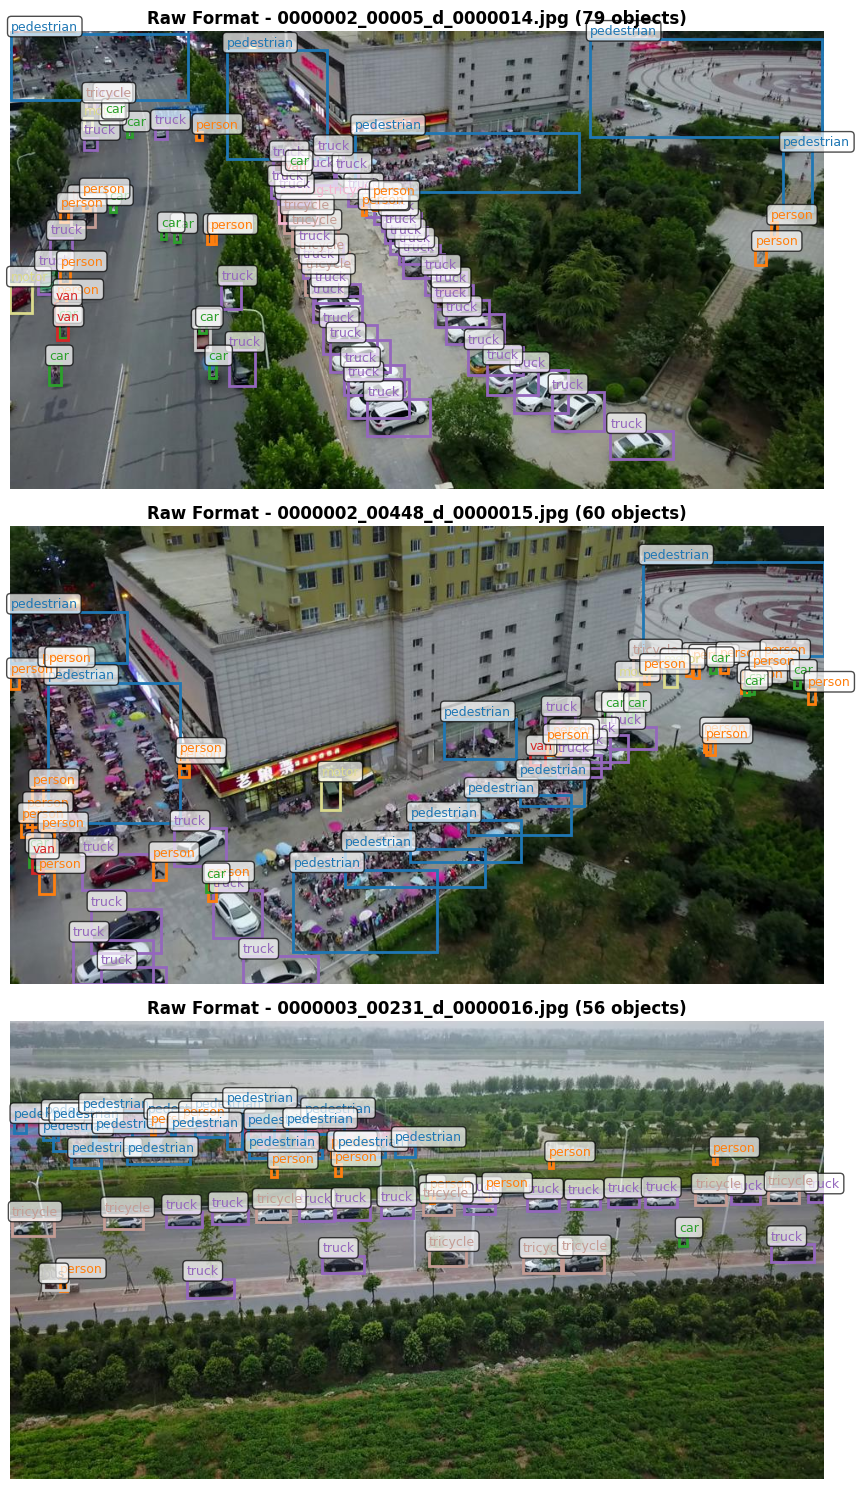

In [5]:
def load_raw_annotations(ann_file):
    """Load VisDrone raw format annotations (x, y, w, h, score, class_id, truncation, occlusion)"""
    bboxes = []
    with open(ann_file, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            
            parts = line.split(',')
            if len(parts) >= 6:
                try:
                    x, y, w, h = float(parts[0]), float(parts[1]), float(parts[2]), float(parts[3])
                    class_id = int(parts[5])
                    
                    if w > 0 and h > 0 and 0 <= class_id < len(CLASS_NAMES):
                        bboxes.append({
                            'x': x, 'y': y, 'w': w, 'h': h,
                            'class_id': class_id,
                            'class_name': CLASS_NAMES[class_id]
                        })
                except:
                    pass
    
    return bboxes


def visualize_raw_format(split="train", num_images=3):
    """Visualize raw VisDrone format with bounding boxes"""
    
    visdrone_split = f"VisDrone2019-DET-{split}"
    split_path = RAW_DIR / visdrone_split
    
    images_dir = split_path / "images"
    annotations_dir = split_path / "annotations"
    
    image_files = sorted([f for f in images_dir.glob("*") if f.suffix.lower() in {".jpg", ".jpeg", ".png"}])[:num_images]
    
    fig, axes = plt.subplots(num_images, 1, figsize=(15, 5*num_images))
    if num_images == 1:
        axes = [axes]
    
    colors = plt.cm.tab20(np.linspace(0, 1, len(CLASS_NAMES)))
    
    for idx, img_file in enumerate(image_files):
        # Load image
        img = Image.open(img_file)
        img_width, img_height = img.size
        
        # Load annotations
        ann_file = annotations_dir / f"{img_file.stem}.txt"
        bboxes = load_raw_annotations(ann_file) if ann_file.exists() else []
        
        # Plot
        ax = axes[idx]
        ax.imshow(img)
        ax.set_title(f"Raw Format - {img_file.name} ({len(bboxes)} objects)", fontsize=12, fontweight='bold')
        
        # Draw bounding boxes
        for bbox in bboxes:
            x, y, w, h = bbox['x'], bbox['y'], bbox['w'], bbox['h']
            class_id = bbox['class_id']
            
            rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor=colors[class_id], facecolor='none')
            ax.add_patch(rect)
            
            ax.text(x, y-5, f"{bbox['class_name']}", fontsize=9, color=colors[class_id], 
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
        
        ax.set_axis_off()
    
    plt.tight_layout()
    plt.show()


# Visualize raw format
print("Visualizing RAW VisDrone Format:")
visualize_raw_format(split="train", num_images=3)

## 5. Visualize YOLO Format with Bounding Boxes

Visualizing YOLO Format:


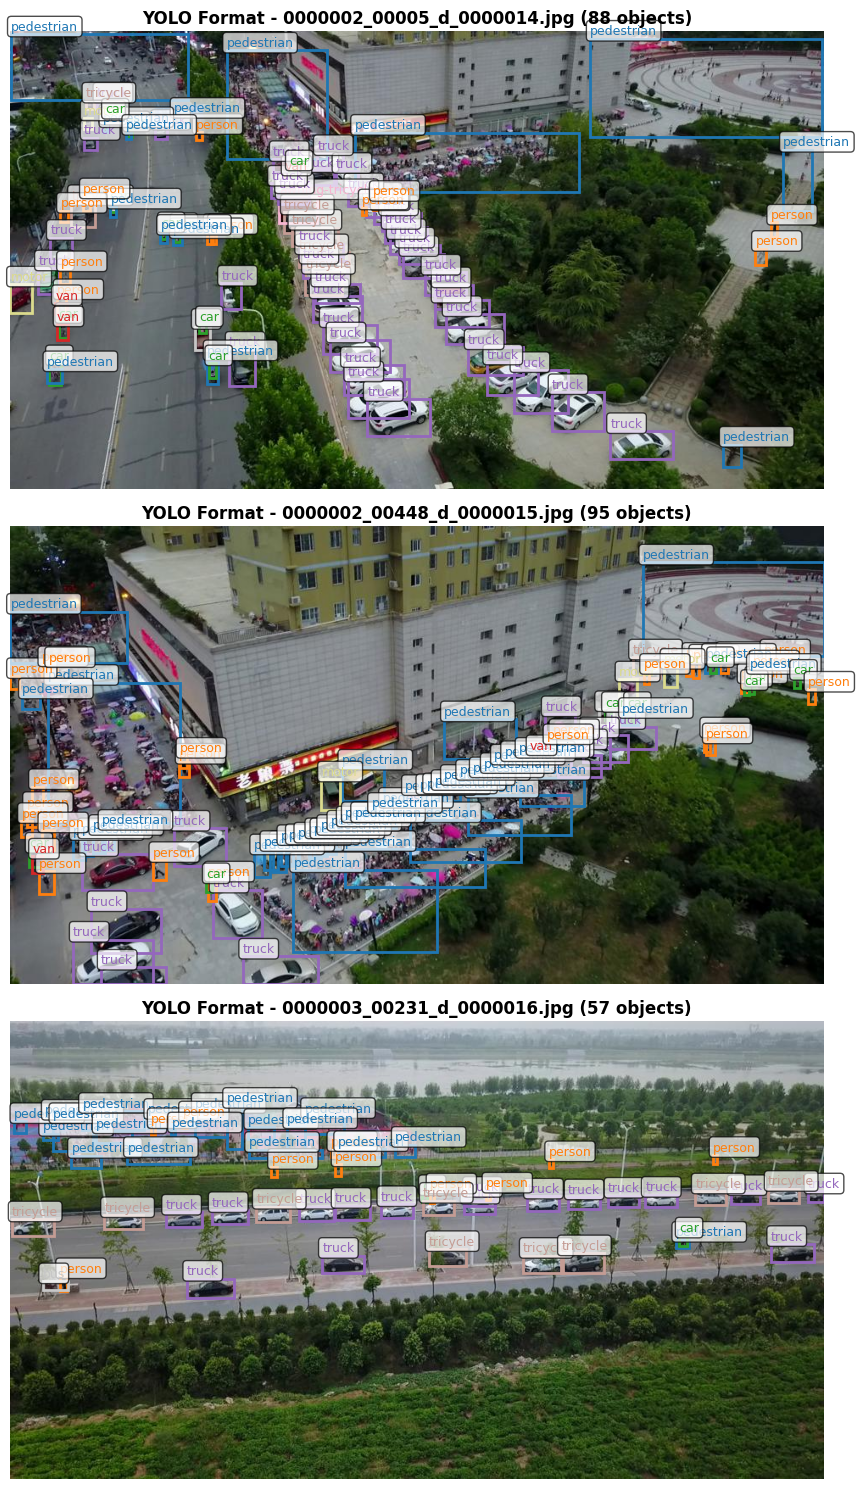

In [6]:
def load_yolo_annotations(label_file):
    """Load YOLO format annotations (class_id, cx, cy, w, h) normalized to [0,1]"""
    bboxes = []
    with open(label_file, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            
            parts = line.split()
            if len(parts) >= 5:
                try:
                    class_id = int(parts[0])
                    cx, cy, w, h = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
                    
                    if 0 <= cx <= 1 and 0 <= cy <= 1 and 0 <= w <= 1 and 0 <= h <= 1 and 0 <= class_id < len(CLASS_NAMES):
                        bboxes.append({
                            'cx': cx, 'cy': cy, 'w': w, 'h': h,
                            'class_id': class_id,
                            'class_name': CLASS_NAMES[class_id]
                        })
                except:
                    pass
    
    return bboxes


def visualize_yolo_format(split="train", num_images=3):
    """Visualize YOLO format with bounding boxes"""
    
    split_path = YOLO_DIR / split
    images_dir = split_path / "images"
    labels_dir = split_path / "labels"
    
    image_files = sorted([f for f in images_dir.glob("*") if f.suffix.lower() in {".jpg", ".jpeg", ".png"}])[:num_images]
    
    fig, axes = plt.subplots(num_images, 1, figsize=(15, 5*num_images))
    if num_images == 1:
        axes = [axes]
    
    colors = plt.cm.tab20(np.linspace(0, 1, len(CLASS_NAMES)))
    
    for idx, img_file in enumerate(image_files):
        # Load image
        img = Image.open(img_file)
        img_width, img_height = img.size
        
        # Load annotations
        label_file = labels_dir / f"{img_file.stem}.txt"
        bboxes = load_yolo_annotations(label_file) if label_file.exists() else []
        
        # Plot
        ax = axes[idx]
        ax.imshow(img)
        ax.set_title(f"YOLO Format - {img_file.name} ({len(bboxes)} objects)", fontsize=12, fontweight='bold')
        
        # Draw bounding boxes (convert from normalized to pixel coordinates)
        for bbox in bboxes:
            cx, cy, w, h = bbox['cx'], bbox['cy'], bbox['w'], bbox['h']
            class_id = bbox['class_id']
            
            # Convert normalized center to pixel coordinates
            x = (cx - w/2) * img_width
            y = (cy - h/2) * img_height
            width = w * img_width
            height = h * img_height
            
            rect = patches.Rectangle((x, y), width, height, linewidth=2, edgecolor=colors[class_id], facecolor='none')
            ax.add_patch(rect)
            
            ax.text(x, y-5, f"{bbox['class_name']}", fontsize=9, color=colors[class_id],
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
        
        ax.set_axis_off()
    
    plt.tight_layout()
    plt.show()


# Visualize YOLO format
print("Visualizing YOLO Format:")
visualize_yolo_format(split="train", num_images=3)

## 6. Conversion Validation: Compare Raw vs YOLO Bounding Boxes

Image: 0000002_00448_d_0000015.jpg
Raw format: 60 objects
YOLO format: 95 objects
Match: ⚠️


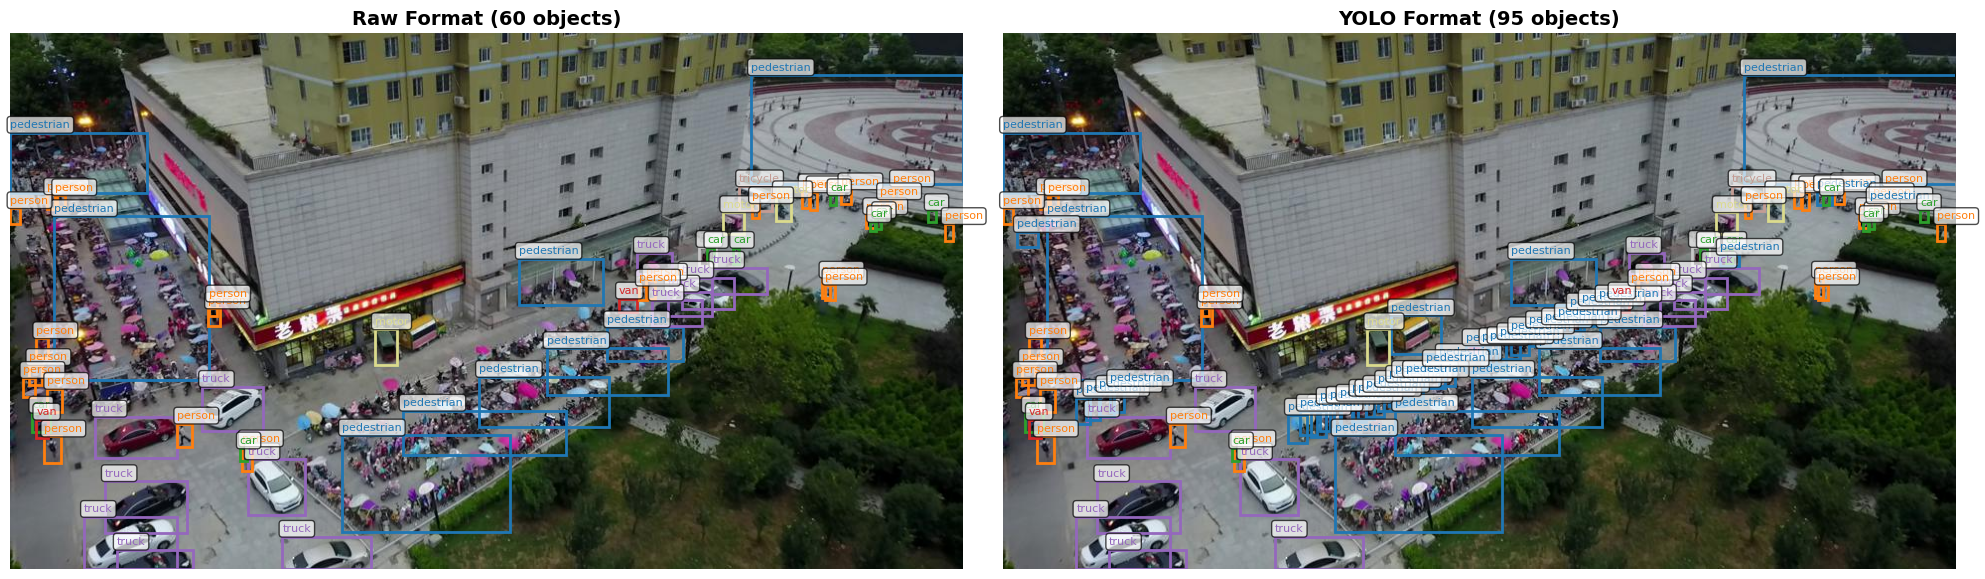


Detailed Comparison:
  ⚠️  Object count mismatch: 60 vs 95


In [7]:
def compare_raw_and_yolo(image_index=0):
    """Compare the same image in raw and YOLO formats side by side"""
    
    # Get raw format
    raw_split = RAW_DIR / "VisDrone2019-DET-train"
    raw_images = sorted([f for f in (raw_split / "images").glob("*") if f.suffix.lower() in {".jpg", ".jpeg", ".png"}])
    raw_img_file = raw_images[image_index]
    raw_ann_file = raw_split / "annotations" / f"{raw_img_file.stem}.txt"
    raw_bboxes = load_raw_annotations(raw_ann_file)
    
    # Get YOLO format (same image should have same name)
    yolo_split = YOLO_DIR / "train"
    yolo_img_file = yolo_split / "images" / raw_img_file.name
    yolo_label_file = yolo_split / "labels" / f"{raw_img_file.stem}.txt"
    yolo_bboxes = load_yolo_annotations(yolo_label_file)
    
    print(f"Image: {raw_img_file.name}")
    print(f"Raw format: {len(raw_bboxes)} objects")
    print(f"YOLO format: {len(yolo_bboxes)} objects")
    print(f"Match: {'✓' if len(raw_bboxes) == len(yolo_bboxes) else '⚠️'}")
    
    # Load image
    img = Image.open(raw_img_file)
    img_width, img_height = img.size
    
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    colors = plt.cm.tab20(np.linspace(0, 1, len(CLASS_NAMES)))
    
    # Plot raw format
    axes[0].imshow(img)
    axes[0].set_title(f"Raw Format ({len(raw_bboxes)} objects)", fontsize=14, fontweight='bold')
    for bbox in raw_bboxes:
        x, y, w, h = bbox['x'], bbox['y'], bbox['w'], bbox['h']
        class_id = bbox['class_id']
        rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor=colors[class_id], facecolor='none')
        axes[0].add_patch(rect)
        axes[0].text(x, y-5, f"{bbox['class_name']}", fontsize=8, color=colors[class_id],
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
    axes[0].set_axis_off()
    
    # Plot YOLO format
    axes[1].imshow(img)
    axes[1].set_title(f"YOLO Format ({len(yolo_bboxes)} objects)", fontsize=14, fontweight='bold')
    for bbox in yolo_bboxes:
        cx, cy, w, h = bbox['cx'], bbox['cy'], bbox['w'], bbox['h']
        class_id = bbox['class_id']
        x = (cx - w/2) * img_width
        y = (cy - h/2) * img_height
        width = w * img_width
        height = h * img_height
        rect = patches.Rectangle((x, y), width, height, linewidth=2, edgecolor=colors[class_id], facecolor='none')
        axes[1].add_patch(rect)
        axes[1].text(x, y-5, f"{bbox['class_name']}", fontsize=8, color=colors[class_id],
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
    axes[1].set_axis_off()
    
    plt.tight_layout()
    plt.show()
    
    # Detailed comparison
    print(f"\nDetailed Comparison:")
    if len(raw_bboxes) == len(yolo_bboxes):
        print(f"  Object counts match ✓")
        
        # Compare class distributions
        raw_classes = [b['class_id'] for b in raw_bboxes]
        yolo_classes = [b['class_id'] for b in yolo_bboxes]
        
        if sorted(raw_classes) == sorted(yolo_classes):
            print(f"  Class distributions match ✓")
        else:
            print(f"  ⚠️  Class distribution mismatch")
            print(f"    Raw: {sorted(raw_classes)}")
            print(f"    YOLO: {sorted(yolo_classes)}")
    else:
        print(f"  ⚠️  Object count mismatch: {len(raw_bboxes)} vs {len(yolo_bboxes)}")


compare_raw_and_yolo(image_index=1)

## 7. Validation Summary

In [8]:
print(f"\n{'='*70}")
print("VALIDATION SUMMARY")
print(f"{'='*70}")

print(f"\n✓ Raw Format Validation:")
for split, data in raw_validation.items():
    print(f"  {split.upper():10s} - {data['images']} images, {data['valid_boxes']} valid boxes")

print(f"\n✓ YOLO Format Validation:")
for split, data in yolo_validation.items():
    print(f"  {split.upper():10s} - {data['images']} images, {data['valid_labels']} valid labels")

print(f"\n✓ Format Correspondence:")
all_match = True
for split in ["train", "val", "test"]:
    raw_count = raw_validation.get(split, {}).get("images", 0)
    yolo_count = yolo_validation.get(split, {}).get("images", 0)
    match = raw_count == yolo_count
    all_match = all_match and match
    status = "✓" if match else "⚠️"
    print(f"  {split.upper():10s} - Raw: {raw_count:5d}, YOLO: {yolo_count:5d} {status}")

print(f"\n{'='*70}")
if all_match:
    print("✓ ALL VALIDATIONS PASSED - Labels are correct!")
else:
    print("⚠️  Some validations failed - Please review the mismatches above")
print(f"{'='*70}")


VALIDATION SUMMARY

✓ Raw Format Validation:
  TRAIN      - 6471 images, 9043 valid boxes
  VAL        - 548 images, 4663 valid boxes
  TEST       - 1610 images, 6559 valid boxes

✓ YOLO Format Validation:
  TRAIN      - 6471 images, 9456 valid labels
  VAL        - 548 images, 5692 valid labels
  TEST       - 1610 images, 6723 valid labels

✓ Format Correspondence:
  TRAIN      - Raw:  6471, YOLO:  6471 ✓
  VAL        - Raw:   548, YOLO:   548 ✓
  TEST       - Raw:  1610, YOLO:  1610 ✓

✓ ALL VALIDATIONS PASSED - Labels are correct!
